---
## 7.0 Imports & Setup

> **Run this cell first.** All imports, aliases, and project modules are here.
> `baseline_models import *` comes first so that `functions_models` explicit imports override it — this prevents the `compute_metrics` signature conflict.

In [1]:
import os, sys, time
from pathlib import Path

# ── Windows DLL fix (must run before heavy imports) ───────────────────────────
if os.name == 'nt':
    _lib_bin = os.path.join(sys.prefix, 'Library', 'bin')
    if os.path.isdir(_lib_bin):
        os.environ['PATH'] = _lib_bin + os.pathsep + os.environ.get('PATH', '')
        if hasattr(os, 'add_dll_directory'):
            try: os.add_dll_directory(_lib_bin)
            except OSError: pass
    import importlib.util as _ilu
    _spec = _ilu.find_spec('torch')
    if _spec and _spec.origin:
        for _subdir in ('lib', 'bin'):
            _d = os.path.join(os.path.dirname(_spec.origin), _subdir)
            if os.path.isdir(_d):
                os.environ['PATH'] = _d + os.pathsep + os.environ.get('PATH', '')
                if hasattr(os, 'add_dll_directory'):
                    try: os.add_dll_directory(_d)
                    except OSError: pass

sys.path.append(os.path.abspath('..'))

# ── Standard / scientific ─────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# ── Visualisation ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
sns.set_theme(style='whitegrid')

# ── Sklearn ───────────────────────────────────────────────────────────────────
from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer, SimpleImputer
from sklearn.preprocessing import RobustScaler, OrdinalEncoder
from sklearn.linear_model import Ridge, Lasso
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# ── Gradient boosting libraries ───────────────────────────────────────────────
import lightgbm as lgb
import xgboost as xgb

# ── Project modules ───────────────────────────────────────────────────────────
# baseline_models wildcard FIRST — then explicit overrides below
from src.code.baseline_models import *

# Qualified alias — always safe, use fm.X anywhere to be explicit
import src.code.functions_models as fm

# Explicit imports AFTER the wildcard → these win the name conflict
from src.code.functions_models import (
    compute_metrics,
    fit_model,
    predict_with_model,
    get_models,
    prepare_subsegment_data,
    prepare_segment_data,
    prepare_bu_data,
    build_segment_level_data,
    build_bu_level_data,
    build_hierarchy_map,
    mint_reconcile,
    build_actuals_dict,
)

%load_ext autoreload
%autoreload 2

print('All imports successful.')

All imports successful.


---
## 7.1 Data Loading

In [2]:
# pathlib handles separators correctly on Windows and Linux/Mac
data_dir   = Path('..') / 'data' / 'features'

train_full = pd.read_parquet(data_dir / 'training_subsegment_fs.parquet')

# Column aliases
TARGET     = 'Revenue cons. (anon)'
ORDERS_COL = 'Orders cons. (anon)'
PERIOD_COL = 'Anon Period'
SUBSEG_COL = 'TGL Business Subsegment'
BU_COL     = 'TGL Business Unit'
SEG_COL    = 'TGL Business Segment'
ID_COLS    = [PERIOD_COL, BU_COL, SEG_COL, SUBSEG_COL]

print(f'train_full shape : {train_full.shape}')
print(f'Periods          : {train_full[PERIOD_COL].min()}\u2013{train_full[PERIOD_COL].max()}')
print(f'Unique subsegments: {train_full[SUBSEG_COL].nunique()}')

train_full shape : (4237, 106)
Periods          : 1–42
Unique subsegments: 134


---
## 7.2 Configuration

Define walk-forward folds and column constants used throughout the notebook.

In [3]:
# Walk-forward parameters
# Cutoffs: models train on periods 1..cutoff and predict cutoff+1
WF_CUTOFFS   = list(range(36, 42))   # 36, 37, 38, 39, 40, 41 → predict 37..42
VAL_PERIODS  = [c + 1 for c in WF_CUTOFFS]

print('Walk-Forward Folds')
print('-' * 30)
for c, v in zip(WF_CUTOFFS, VAL_PERIODS):
    print(f'  Train 1–{c:2d}  →  Predict {v}')

Walk-Forward Folds
------------------------------
  Train 1–36  →  Predict 37
  Train 1–37  →  Predict 38
  Train 1–38  →  Predict 39
  Train 1–39  →  Predict 40
  Train 1–40  →  Predict 41
  Train 1–41  →  Predict 42


---
## 7.3 Function Definitions

All helper functions are defined here in one place.

| Function | Purpose |
|---|---|
| `naive_wf_subsegment` | Naïve / Seasonal Naïve / MA(6) baselines per fold |
| `run_walk_forward` | ML walk-forward engine for any hierarchy level |

In [4]:
# ════════════════════════════════════════════════════════════════
# FUNCTION DEFINITIONS
# Run this cell before any of the execution cells below.
# ════════════════════════════════════════════════════════════════

def naive_wf_subsegment(df, cutoffs, target=TARGET, period_col=PERIOD_COL,
                         subseg_col=SUBSEG_COL):
    """
    Computes Naïve, Seasonal Naïve and MA(6) baselines at subsegment level
    for each walk-forward fold. Returns a DataFrame of per-fold metrics.
    """
    records = []
    for cutoff in cutoffs:
        val_period = cutoff + 1
        train_df = df[df[period_col] <= cutoff]
        val_df   = df[df[period_col] == val_period]

        y_naive, y_snaive, y_ma6 = [], [], []
        y_true_list = []

        for sub in val_df[subseg_col].unique():
            sub_train = train_df[train_df[subseg_col] == sub].sort_values(period_col)
            sub_val   = val_df[val_df[subseg_col] == sub]
            if len(sub_val) == 0 or len(sub_train) == 0:
                continue
            y_act = sub_val[target].values[0]
            series = sub_train[target].values

            y_true_list.append(y_act)
            # Naïve: last known value
            y_naive.append(series[-1])
            # Seasonal Naïve: same period 12 months ago
            y_snaive.append(series[-12] if len(series) >= 12 else series[0])
            # MA(6): mean of last 6 known values
            y_ma6.append(np.mean(series[-6:]) if len(series) >= 6 else np.mean(series))

        y_true_arr = np.array(y_true_list)
        for name, preds in [('Naïve', y_naive),
                             ('Seasonal Naïve', y_snaive),
                             ('Moving Avg (6)', y_ma6)]:
            m = fm.compute_metrics(y_true_arr, np.array(preds), name, 'Subsegment')
            m['cutoff'] = cutoff
            m['val_period'] = val_period
            records.append(m)

    return pd.DataFrame(records)

baseline_results = naive_wf_subsegment(train_full, WF_CUTOFFS)

print('Naive Baselines — Per-Fold RMSE (Subsegment level)')
(baseline_results.pivot(index='val_period', columns='Model', values='RMSE')
 .style.format('{:,.0f}'))


def run_walk_forward(df_level, level_name, feature_cols, cat_cols,
                     cutoffs, target=TARGET, period_col=PERIOD_COL,
                     verbose=True):
    """
    Walk-forward validation: for each cutoff, train on [1..cutoff], predict cutoff+1.

    Works for Subsegment, Segment, and BU levels.
    Metrics are aggregated across all series within the level for each fold.

    Parameters
    ----------
    df_level     : full dataset at that level (all periods)
    level_name   : 'Subsegment' | 'Segment' | 'BU'
    feature_cols : feature column list (from prepare_* functions)
    cat_cols     : categorical column list
    cutoffs      : list of cutoff periods (e.g. [36, 37, 38, 39, 40, 41])

    Returns
    -------
    pd.DataFrame with columns:
        [Model, Level, cutoff, val_period, RMSE, MAE, wMAPE, R2, N_samples, elapsed_s]
    """
    models   = fm.get_models(cat_cols, feature_cols)
    all_rows = []

    for cutoff in cutoffs:
        val_period = cutoff + 1
        train_df   = df_level[df_level[period_col] <= cutoff].copy()
        val_df     = df_level[df_level[period_col] == val_period].copy()

        if len(val_df) == 0:
            print(f'  [{level_name}] Skipping cutoff={cutoff}: no data at period {val_period}')
            continue

        # Encode categoricals
        for c in cat_cols:
            if c in feature_cols:
                train_df[c] = train_df[c].astype('category')
                val_df[c]   = val_df[c].astype('category')

        X_tr  = train_df[feature_cols]
        y_tr  = train_df[target].values
        X_val = val_df[feature_cols]
        y_val = val_df[target].values

        if verbose:
            print(f'  [{level_name}] cutoff={cutoff} → predict {val_period} '
                  f'| train={len(train_df)} rows, val={len(val_df)} rows')

        for name, (template, needs_pp) in models.items():
            t0 = time.time()
            try:
                mdl    = clone(template)
                fitted, pp = fm.fit_model(mdl, X_tr, y_tr, needs_pp, cat_cols, feature_cols)
                preds  = predict_with_model(fitted, X_val, needs_pp, pp, cat_cols, feature_cols)
                m      = fm.compute_metrics(y_val, preds, name, level_name)
            except Exception as e:
                print(f'    FAILED — {name} @ cutoff={cutoff}: {e}')
                m = {'Model': name, 'Level': level_name,
                     'RMSE': np.nan, 'MAE': np.nan, 'wMAPE': np.nan,
                     'R2': np.nan, 'N_samples': 0}

            m['cutoff']     = cutoff
            m['val_period'] = val_period
            m['elapsed_s']  = round(time.time() - t0, 2)
            all_rows.append(m)

    cols = ['Model', 'Level', 'cutoff', 'val_period', 'RMSE', 'MAE', 'wMAPE', 'R2', 'N_samples', 'elapsed_s']
    df_out = pd.DataFrame(all_rows)
    return df_out[[c for c in cols if c in df_out.columns]]

print('Walk-forward engine ready.')

Naive Baselines — Per-Fold RMSE (Subsegment level)
Walk-forward engine ready.


---
## 7.4 Build Level Datasets

Subsegment features come from the parquet. Segment and BU are aggregated once from `train_full` — no per-fold rebuild needed since lag features use `.shift()` and don't leak future values.

In [5]:


# --- Subsegment: features already in parquet ---
# Get feature_cols and cat_cols by calling prepare once (they don't change across folds)
_, _, _, _, feature_cols_sub, cat_cols_sub = prepare_subsegment_data(
    df=train_full, val_cutoff=36
)
print(f'Subsegment — {len(feature_cols_sub)} features, cats: {cat_cols_sub}')

# --- Segment: aggregate + compute lags ---
seg_full = build_segment_level_data(train_full)
_, _, _, _, feature_cols_seg, cat_cols_seg = prepare_segment_data(
    seg_df=seg_full, val_cutoff=36
)
print(f'Segment    — {len(feature_cols_seg)} features, cats: {cat_cols_seg}')

# --- BU: aggregate + compute lags ---
bu_full = build_bu_level_data(train_full)
_, _, _, _, feature_cols_bu, cat_cols_bu = prepare_bu_data(
    bu_df=bu_full, val_cutoff=36
)
print(f'BU         — {len(feature_cols_bu)} features, cats: {cat_cols_bu}')

Subsegment — 54 features, cats: ['TGL Business Unit', 'TGL Business Segment', 'TGL Business Subsegment']
Segment-level dataset: (791, 30)
Segment    — 26 features, cats: ['TGL Business Unit', 'TGL Business Segment']
BU-level dataset: (168, 29)
BU         — 25 features, cats: ['TGL Business Unit']


---
## 7.5 Naive Baselines

Computed per fold so they are on the same footing as ML models.

| Baseline | Formula |
|----------|---------|
| **Naïve** | $\hat{y}_{t+1} = y_t$ |
| **Seasonal Naïve** | $\hat{y}_{t+1} = y_{t+1-12}$ |
| **Moving Avg (6)** | $\hat{y}_{t+1} = \text{mean}(y_{t-5}, \ldots, y_t)$ |

In [6]:
baseline_results = naive_wf_subsegment(train_full, WF_CUTOFFS)

print('Naive Baselines — Per-Fold RMSE (Subsegment level)')
(baseline_results.pivot(index='val_period', columns='Model', values='RMSE')
 .style.format('{:,.0f}'))

Naive Baselines — Per-Fold RMSE (Subsegment level)


Model,Moving Avg (6),Naïve,Seasonal Naïve
val_period,,,
37,"13,761,640","28,727,492","11,192,902"
38,"6,698,723","10,953,673","9,085,959"
39,"8,508,493","9,910,898","15,820,611"
40,"6,733,938","12,401,650","10,500,947"
41,"5,481,853","4,360,671","12,080,936"
42,"10,800,125","10,378,086","13,132,328"


---
## 7.6 Run Walk-Forward — Subsegment Level

In [7]:
print('=== SUBSEGMENT LEVEL ===')
t_start = time.time()

wf_sub = run_walk_forward(
    df_level     = train_full,
    level_name   = 'Subsegment',
    feature_cols = feature_cols_sub,
    cat_cols     = cat_cols_sub,
    cutoffs      = WF_CUTOFFS,
)

print(f'\nDone in {time.time() - t_start:.0f}s')

=== SUBSEGMENT LEVEL ===
  [Subsegment] cutoff=36 → predict 37 | train=3524 rows, val=115 rows
    FAILED — CatBoost @ cutoff=36: Cannot clone object CatBoostRegressor(cat_features=[0, 1, 2], depth=6, iterations=500, learning_rate=0.05, loss_function='RMSE', random_seed=42, verbose=0), as the constructor either does not set or modifies parameter cat_features
  [Subsegment] cutoff=37 → predict 38 | train=3639 rows, val=117 rows
    FAILED — CatBoost @ cutoff=37: Cannot clone object CatBoostRegressor(cat_features=[0, 1, 2], depth=6, iterations=500, learning_rate=0.05, loss_function='RMSE', random_seed=42, verbose=0), as the constructor either does not set or modifies parameter cat_features
  [Subsegment] cutoff=38 → predict 39 | train=3756 rows, val=123 rows
    FAILED — CatBoost @ cutoff=38: Cannot clone object CatBoostRegressor(cat_features=[0, 1, 2], depth=6, iterations=500, learning_rate=0.05, loss_function='RMSE', random_seed=42, verbose=0), as the constructor either does not set or

---
## 7.7 Run Walk-Forward — Segment Level

In [8]:
print('=== SEGMENT LEVEL ===')
t_start = time.time()

wf_seg = run_walk_forward(
    df_level     = seg_full,
    level_name   = 'Segment',
    feature_cols = feature_cols_seg,
    cat_cols     = cat_cols_seg,
    cutoffs      = WF_CUTOFFS,
)

print(f'\nDone in {time.time() - t_start:.0f}s')

=== SEGMENT LEVEL ===
  [Segment] cutoff=36 → predict 37 | train=672 rows, val=18 rows
    FAILED — CatBoost @ cutoff=36: Cannot clone object CatBoostRegressor(cat_features=[0, 1], depth=6, iterations=500, learning_rate=0.05, loss_function='RMSE', random_seed=42, verbose=0), as the constructor either does not set or modifies parameter cat_features
  [Segment] cutoff=37 → predict 38 | train=690 rows, val=20 rows
    FAILED — CatBoost @ cutoff=37: Cannot clone object CatBoostRegressor(cat_features=[0, 1], depth=6, iterations=500, learning_rate=0.05, loss_function='RMSE', random_seed=42, verbose=0), as the constructor either does not set or modifies parameter cat_features
  [Segment] cutoff=38 → predict 39 | train=710 rows, val=20 rows
    FAILED — CatBoost @ cutoff=38: Cannot clone object CatBoostRegressor(cat_features=[0, 1], depth=6, iterations=500, learning_rate=0.05, loss_function='RMSE', random_seed=42, verbose=0), as the constructor either does not set or modifies parameter cat_fea

---
## 7.8 Run Walk-Forward — BU Level

In [9]:
print('=== BU LEVEL ===')
t_start = time.time()

wf_bu = run_walk_forward(
    df_level     = bu_full,
    level_name   = 'BU',
    feature_cols = feature_cols_bu,
    cat_cols     = cat_cols_bu,
    cutoffs      = WF_CUTOFFS,
)

print(f'\nDone in {time.time() - t_start:.0f}s')

=== BU LEVEL ===
  [BU] cutoff=36 → predict 37 | train=144 rows, val=4 rows
    FAILED — CatBoost @ cutoff=36: Cannot clone object CatBoostRegressor(cat_features=[0], depth=6, iterations=500, learning_rate=0.05, loss_function='RMSE', random_seed=42, verbose=0), as the constructor either does not set or modifies parameter cat_features
  [BU] cutoff=37 → predict 38 | train=148 rows, val=4 rows
    FAILED — CatBoost @ cutoff=37: Cannot clone object CatBoostRegressor(cat_features=[0], depth=6, iterations=500, learning_rate=0.05, loss_function='RMSE', random_seed=42, verbose=0), as the constructor either does not set or modifies parameter cat_features
  [BU] cutoff=38 → predict 39 | train=152 rows, val=4 rows
    FAILED — CatBoost @ cutoff=38: Cannot clone object CatBoostRegressor(cat_features=[0], depth=6, iterations=500, learning_rate=0.05, loss_function='RMSE', random_seed=42, verbose=0), as the constructor either does not set or modifies parameter cat_features
  [BU] cutoff=39 → predict

---
## 7.9 Results — Summary by Model

Average metrics across all 6 folds for each model and hierarchy level.

In [10]:
# Combine all levels + baselines
wf_all = pd.concat([wf_sub, wf_seg, wf_bu], ignore_index=True)

# Add baseline results for subsegment level to the combined frame
wf_with_baselines = pd.concat([wf_all, baseline_results], ignore_index=True)

# Summary: mean across folds
summary = (
    wf_with_baselines
    .groupby(['Level', 'Model'])[['RMSE', 'MAE', 'wMAPE', 'R2']]
    .mean()
    .reset_index()
    .sort_values(['Level', 'RMSE'])
)

for level in ['BU', 'Segment', 'Subsegment']:
    level_df = summary[summary['Level'] == level].copy()
    if len(level_df) == 0:
        continue
    print(f'\n{"=" * 65}')
    print(f'  {level} Level — Average across {len(WF_CUTOFFS)} folds')
    print(f'{"=" * 65}')
    display_df = level_df.drop(columns='Level').copy()
    display_df['RMSE']  = display_df['RMSE'].apply(lambda x: f"{x:>15,.0f}")
    display_df['MAE']   = display_df['MAE'].apply(lambda x: f"{x:>12,.0f}")
    display_df['wMAPE'] = display_df['wMAPE'].apply(lambda x: f"{x:>7.1f}%")
    display_df['R2']    = display_df['R2'].apply(lambda x: f"{x:>8.4f}")
    print(display_df.to_string(index=False))


  BU Level — Average across 6 folds
            Model            RMSE          MAE    wMAPE       R2
         LightGBM      79,567,159   64,760,391     6.5%   0.9775
          XGBoost      79,799,423   60,455,591     6.0%   0.9748
            Ridge      88,226,217   72,580,115     7.2%   0.9718
            Lasso      89,396,968   72,306,495     7.2%   0.9711
Gradient Boosting      92,325,956   66,874,851     6.6%   0.9694
    Random Forest     107,849,478   82,595,137     8.0%   0.9575
       ElasticNet     206,984,115  186,006,714    18.1%   0.8552
         CatBoost             nan          nan     nan%      nan

  Segment Level — Average across 6 folds
            Model            RMSE          MAE    wMAPE       R2
          XGBoost      26,351,418   12,791,378     6.3%   0.9921
Gradient Boosting      29,500,780   16,366,588     8.0%   0.9899
         LightGBM      29,939,074   14,325,608     7.0%   0.9893
            Ridge      39,312,172   23,044,018    11.3%   0.9822
           

In [11]:
def get_wf_aggregate_preds(df_level, feature_cols, cat_cols, model_name,
                            cutoffs, target=TARGET, period_col=PERIOD_COL):
    """
    Re-corre o walk-forward para UM modelo e devolve a previsão
    agregada (soma de todas as séries) por período de validação.
    """
    template, needs_pp = fm.get_models(cat_cols, feature_cols)[model_name]
    agg_preds = {}

    for cutoff in cutoffs:
        val_period = cutoff + 1
        train_df = df_level[df_level[period_col] <= cutoff].copy()
        val_df   = df_level[df_level[period_col] == val_period].copy()

        for c in cat_cols:
            if c in feature_cols:
                train_df[c] = train_df[c].astype('category')
                val_df[c]   = val_df[c].astype('category')

        mdl = clone(template)
        fitted, pp = fm.fit_model(mdl, train_df[feature_cols],
                                  train_df[target].values,
                                  needs_pp, cat_cols, feature_cols)
        preds = fm.predict_with_model(fitted, val_df[feature_cols],
                                      needs_pp, pp, cat_cols, feature_cols)
        agg_preds[val_period] = np.sum(preds)

    return agg_preds


def plot_forecast_area(train_full, agg_preds, model_name,
                       target=TARGET, period_col=PERIOD_COL, figsize=(14, 5)):
    """
    Histórico completo a azul + previsões walk-forward a laranja por cima,
    à semelhança do gráfico do vídeo.
    """
    actuals     = train_full.groupby(period_col)[target].sum().sort_index()
    periods     = actuals.index.tolist()
    actual_vals = actuals.values

    val_periods = sorted(agg_preds.keys())
    pred_vals   = [agg_preds[p] for p in val_periods]
    cutoff_x    = val_periods[0] - 0.5

    fig, ax = plt.subplots(figsize=figsize)

    # Histórico completo — azul
    ax.fill_between(periods, actual_vals, alpha=0.80,
                    color='#378ADD', label='Actual Revenue')
    ax.plot(periods, actual_vals, color='#185FA5', linewidth=0.6)

    # Previsões — laranja por cima
    ax.fill_between(val_periods, pred_vals, alpha=0.85,
                    color='#D85A30', label=f'{model_name} — Walk-Forward')
    ax.plot(val_periods, pred_vals, color='#993C1D',
            linewidth=1.5, marker='o', markersize=5, zorder=5)

    # Linha divisória treino / validação
    ax.axvline(cutoff_x, color='white', linewidth=1.8,
               linestyle='--', alpha=0.8)
    ax.text(cutoff_x + 0.15, ax.get_ylim()[1] * 0.96,
            'validation →', fontsize=9,
            color='white', va='top', alpha=0.9)

    ax.yaxis.set_major_formatter(
        plt.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))
    ax.set_xlabel('Period', fontsize=11)
    ax.set_ylabel('Total Revenue', fontsize=11)
    ax.set_title(
        f'Walk-Forward Forecast — {model_name}  '
        f'(val periods {val_periods[0]}–{val_periods[-1]})',
        fontsize=12)
    ax.legend(fontsize=10, framealpha=0.3, loc='upper left')
    ax.set_facecolor('#1a1a2e')  # fundo escuro como no vídeo
    fig.patch.set_facecolor('#1a1a2e')
    ax.tick_params(colors='white')
    ax.xaxis.label.set_color('white')
    ax.yaxis.label.set_color('white')
    ax.title.set_color('white')
    for spine in ax.spines.values():
        spine.set_edgecolor('#444')

    plt.tight_layout()
    plt.show()



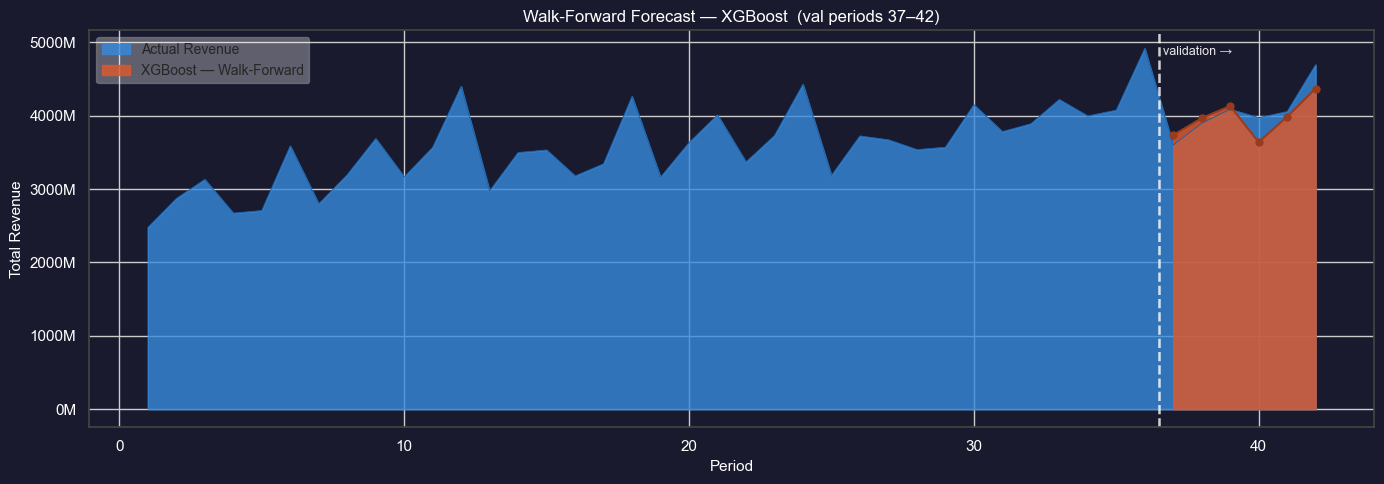

In [12]:
agg_preds_xgb = get_wf_aggregate_preds(
    train_full, feature_cols_sub, cat_cols_sub,
    model_name='XGBoost', cutoffs=WF_CUTOFFS
)

plot_forecast_area(train_full, agg_preds_xgb, 'XGBoost')

In [13]:
def plot_actual_vs_pred_scatter(wf_sub_raw, train_full, model_name,
                                 target=TARGET, period_col=PERIOD_COL):
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    axes = axes.flatten()

    for fi, cutoff in enumerate(WF_CUTOFFS):
        val_period = cutoff + 1
        ax = axes[fi]

        actuals = train_full[train_full[period_col] == val_period][target].values
        preds   = wf_sub_raw[cutoff][model_name]

        lim = max(np.percentile(np.abs(actuals), 98),
                  np.percentile(np.abs(preds), 98)) * 1.1

        ax.scatter(actuals, preds, alpha=0.5, s=18,
                   color='#378ADD', edgecolors='none')
        ax.plot([0, lim], [0, lim], color='#D85A30',
                linewidth=1.5, linestyle='--', label='perfect')

        r2    = r2_score(actuals, preds)
        wmape = np.sum(np.abs(actuals-preds)) / np.sum(np.abs(actuals)) * 100

        ax.set_title(f'Period {val_period}  |  R²={r2:.3f}  wMAPE={wmape:.1f}%',
                     fontsize=10)
        ax.set_xlabel('Actual', fontsize=9)
        ax.set_ylabel('Predicted', fontsize=9)
        ax.set_xlim(0, lim); ax.set_ylim(0, lim)
        ax.xaxis.set_major_formatter(
            plt.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))
        ax.yaxis.set_major_formatter(
            plt.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))

    plt.suptitle(f'{model_name} — Actual vs Predicted per Series & Fold',
                 fontsize=13)
    plt.tight_layout()
    plt.show()

---
## 7.9.1 MinT Hierarchical Reconciliation

Base forecasts at subsegment level tend to **inflate** over recursive horizons because small positive biases accumulate step-by-step. Aggregate levels (Segment, BU) are more stable since individual errors partially cancel.

**MinT** (Minimum Trace reconciliation) exploits this by:
1. Collecting base forecasts from **all 3 levels** independently
2. Estimating each level's error covariance from in-sample residuals
3. Projecting reconciled bottom-level forecasts that are **coherent** (subsegments sum exactly to segments/BUs) and **shrunk** toward the more reliable aggregates

This reduces inflation without manually capping or clipping predictions.

In [14]:
# ═══════════════════════════════════════════════════════════════
# Build hierarchy map & actuals dicts
# ═══════════════════════════════════════════════════════════════

# --- Hierarchy map (summing matrix S) ---
hier = fm.build_hierarchy_map(train_full, BU_COL, SEG_COL, SUBSEG_COL)
print(f"Hierarchy: {hier['n_bottom']} subsegments → "
      f"{hier['n_seg']} segments → {hier['n_bu']} BUs → 1 Total")
print(f"Summing matrix S shape: {hier['S'].shape}")

# --- Actuals dicts (for residual covariance) ---
GROUP_SUB = [BU_COL, SEG_COL, SUBSEG_COL]
GROUP_SEG = [BU_COL, SEG_COL]
GROUP_BU  = [BU_COL]

actuals_sub = fm.build_actuals_dict(train_full, GROUP_SUB, TARGET, PERIOD_COL)
actuals_seg = fm.build_actuals_dict(seg_full,   GROUP_SEG, TARGET, PERIOD_COL)
actuals_bu  = fm.build_actuals_dict(bu_full,    GROUP_BU,  TARGET, PERIOD_COL)

print(f"\nActuals built: {len(actuals_sub)} subseg, "
      f"{len(actuals_seg)} seg, {len(actuals_bu)} BU series")

Hierarchy: 134 subsegments → 24 segments → 4 BUs → 1 Total
Summing matrix S shape: (163, 134)

Actuals built: 134 subseg, 24 seg, 4 BU series


In [15]:
# ═══════════════════════════════════════════════════════════════
# Learn MinT error covariance (internal validation split)
# ═══════════════════════════════════════════════════════════════
#
# We use an INTERNAL split (train 1-36, val 37-42) to estimate
# the residual covariance matrix W that MinT needs.
# This tells MinT which levels/series have reliable forecasts
# and which tend to inflate — so it knows how much to correct.
#
# The actual reconciliation of periods 43-48 happens in Cell 36.

MINT_CUTOFF = 36  # internal split: train 1-36, validate 37-42

# --- Subsegment: estimate errors ---
print('=== Learning error structure: SUBSEGMENT ===')
_, fc_sub_cv, fitted_sub_cv = fm.run_recursive_benchmark(
    train_full, val_cutoff=MINT_CUTOFF,
    feature_cols=feature_cols_sub, cat_cols=cat_cols_sub,
    level_name='Subsegment', group_cols=GROUP_SUB,
    target=TARGET, absolute_target=TARGET, period_col=PERIOD_COL,
)

# --- Segment: estimate errors ---
print('\n=== Learning error structure: SEGMENT ===')
_, fc_seg_cv, fitted_seg_cv = fm.run_recursive_benchmark(
    seg_full, val_cutoff=MINT_CUTOFF,
    feature_cols=feature_cols_seg, cat_cols=cat_cols_seg,
    level_name='Segment', group_cols=GROUP_SEG,
    target=TARGET, absolute_target=TARGET, period_col=PERIOD_COL,
)

# --- BU: estimate errors ---
print('\n=== Learning error structure: BU ===')
_, fc_bu_cv, fitted_bu_cv = fm.run_recursive_benchmark(
    bu_full, val_cutoff=MINT_CUTOFF,
    feature_cols=feature_cols_bu, cat_cols=cat_cols_bu,
    level_name='BU', group_cols=GROUP_BU,
    target=TARGET, absolute_target=TARGET, period_col=PERIOD_COL,
)

print('\nError covariance estimation complete.')
print('MinT will use these fitted values to build the shrinkage matrix W.')


=== Learning error structure: SUBSEGMENT ===
  LightGBM @ Subsegment ... Val RMSE:     34,438,584 | Train R²:  0.9962 | 1.8s
  XGBoost @ Subsegment ... Val RMSE:     27,921,629 | Train R²:  0.9968 | 1.9s
  Ridge @ Subsegment ... Val RMSE:  1,962,033,198 | Train R²:  0.9379 | 1.0s
  Lasso @ Subsegment ... Val RMSE:  1,962,064,571 | Train R²:  0.9382 | 1.3s
  ElasticNet @ Subsegment ... Val RMSE:  1,961,847,800 | Train R²:  0.7981 | 1.0s
  Random Forest @ Subsegment ... Val RMSE:     52,577,603 | Train R²:  0.9542 | 1.8s
  Gradient Boosting @ Subsegment ... Val RMSE:     71,168,147 | Train R²:  0.9694 | 3.6s
  CatBoost @ Subsegment ... FAILED - Cannot clone object CatBoostRegressor(cat_features=[0, 1, 2], depth=6, iterations=500, learning_rate=0.05, loss_function='RMSE', random_seed=42, verbose=0), as the constructor either does not set or modifies parameter cat_features

=== Learning error structure: SEGMENT ===
  LightGBM @ Segment ... Val RMSE:     31,888,124 | Train R²:  0.9943 | 0.5

---
## 7.10 Per-Fold Metrics: RMSE Stability

Line plot of RMSE per fold for each model. A good model has **consistent** RMSE across folds, not just a low average.

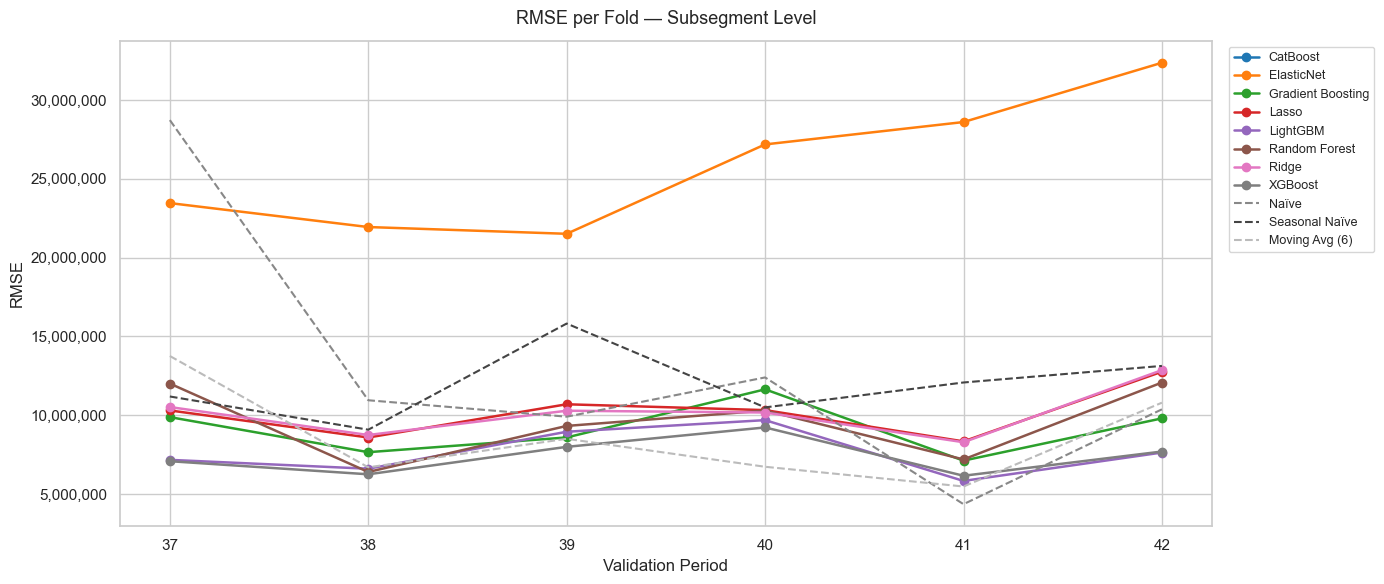

In [16]:
def plot_per_fold_rmse(wf_df, baseline_df, level='Subsegment', metric='RMSE', figsize=(14, 6)):
    """Line plot of per-fold metric for all models at a given hierarchy level."""
    df     = wf_df[wf_df['Level'] == level].copy()
    bdf    = baseline_df[baseline_df['Level'] == level].copy()
    models = df['Model'].unique()

    fig, ax = plt.subplots(figsize=figsize)

    # ML models
    palette = sns.color_palette('tab10', len(models))
    for i, model in enumerate(sorted(models)):
        sub = df[df['Model'] == model].sort_values('val_period')
        ax.plot(sub['val_period'], sub[metric], marker='o', label=model, color=palette[i], linewidth=1.8)

    # Baselines (dashed)
    base_palette = ['#888888', '#444444', '#bbbbbb']
    for j, bname in enumerate(bdf['Model'].unique()):
        bsub = bdf[bdf['Model'] == bname].sort_values('val_period')
        ax.plot(bsub['val_period'], bsub[metric], linestyle='--',
                label=bname, color=base_palette[j % len(base_palette)], linewidth=1.5)

    ax.set_title(f'{metric} per Fold — {level} Level', fontsize=13, pad=12)
    ax.set_xlabel('Validation Period')
    ax.set_ylabel(metric)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
    ax.set_xticks(VAL_PERIODS)
    ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
    plt.tight_layout()
    plt.show()

plot_per_fold_rmse(wf_all, baseline_results, level='Subsegment', metric='RMSE')

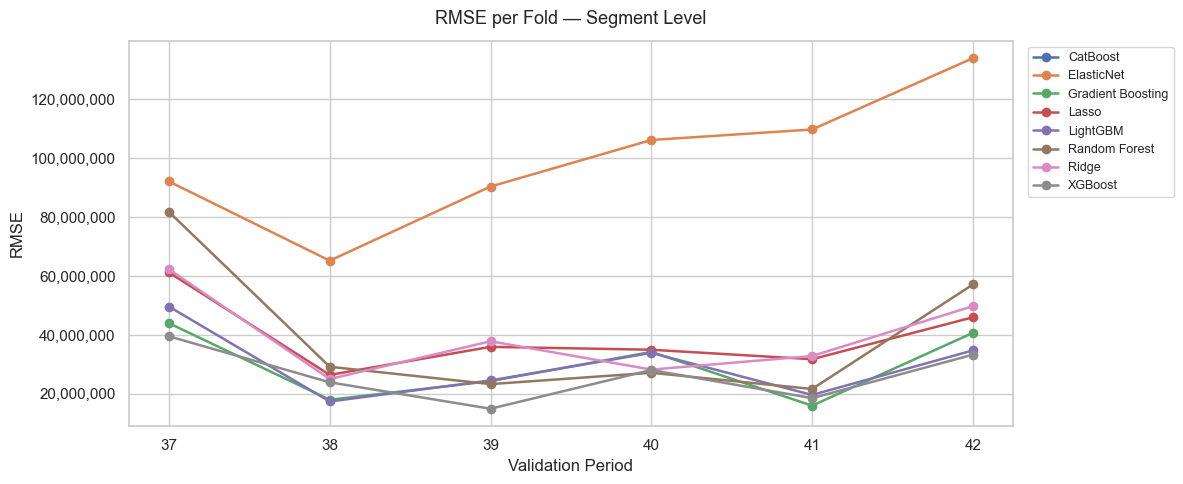

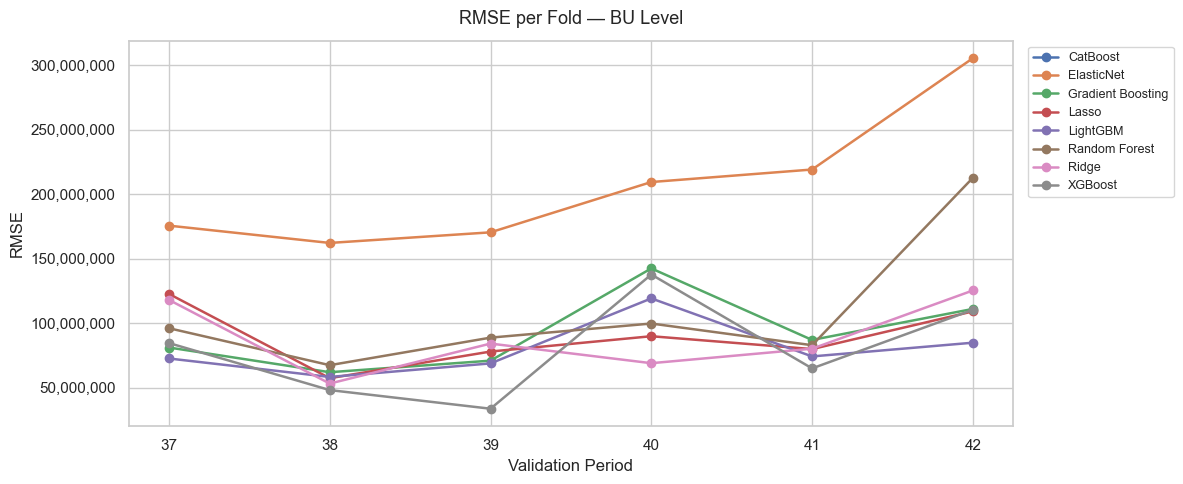

In [17]:
# Same for Segment and BU

def plot_per_fold_level(wf_df, level, metric='RMSE', figsize=(12, 5)):
    df     = wf_df[wf_df['Level'] == level].copy()
    models = sorted(df['Model'].unique())
    fig, ax = plt.subplots(figsize=figsize)
    for i, model in enumerate(models):
        sub = df[df['Model'] == model].sort_values('val_period')
        ax.plot(sub['val_period'], sub[metric], marker='o', label=model, linewidth=1.8)
    ax.set_title(f'{metric} per Fold — {level} Level', fontsize=13, pad=12)
    ax.set_xlabel('Validation Period')
    ax.set_ylabel(metric)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
    ax.set_xticks(VAL_PERIODS)
    ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
    plt.tight_layout()
    plt.show()

plot_per_fold_level(wf_all, 'Segment')
plot_per_fold_level(wf_all, 'BU')

---
## 7.11 Heatmap: Model × Fold

Spot models that are consistently good vs. those that collapse on specific folds.

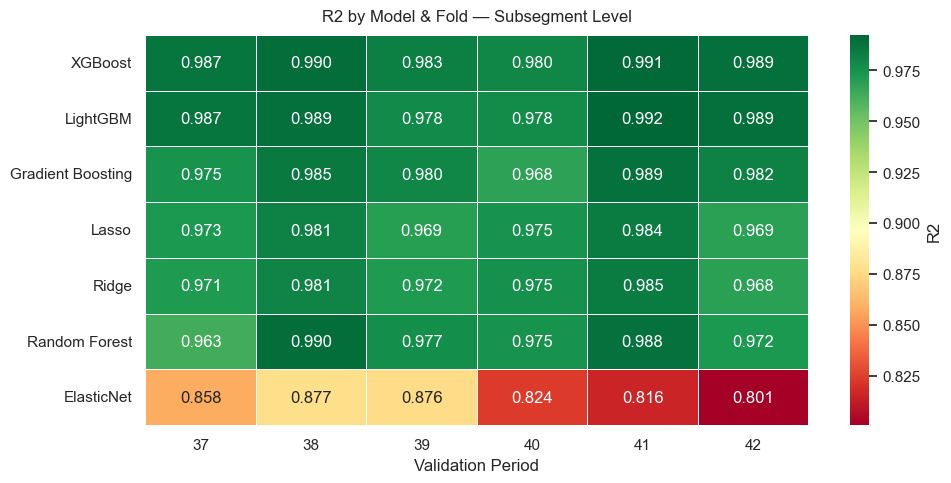

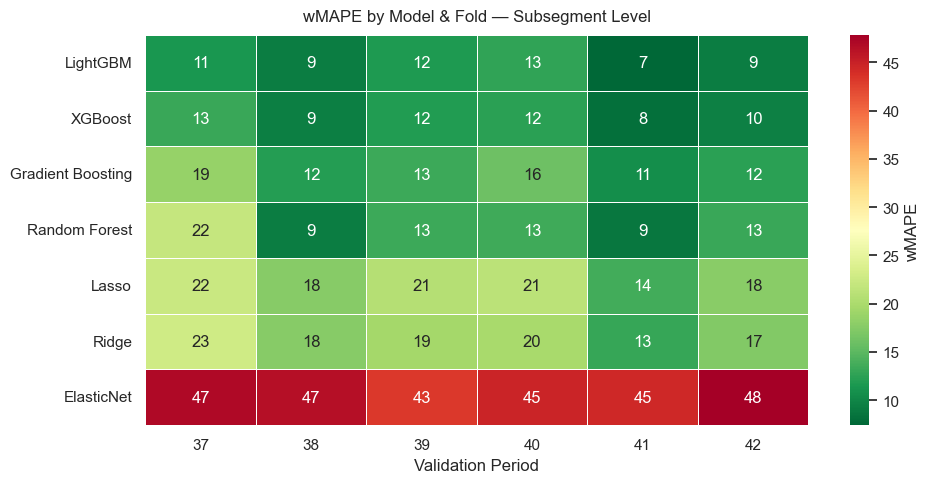

In [18]:
def plot_fold_heatmap(wf_df, level='Subsegment', metric='R2', figsize=(10, 5)):
    df  = wf_df[wf_df['Level'] == level].copy()
    piv = df.pivot_table(index='Model', columns='val_period', values=metric, aggfunc='mean')
    piv = piv.sort_values(by=piv.columns.tolist(), ascending=(metric != 'R2'))

    cmap = 'RdYlGn' if metric == 'R2' else 'RdYlGn_r'
    fig, ax = plt.subplots(figsize=figsize)
    sns.heatmap(
        piv, annot=True, fmt='.3f' if metric == 'R2' else '.0f',
        cmap=cmap, linewidths=0.5, ax=ax,
        cbar_kws={'label': metric}
    )
    ax.set_title(f'{metric} by Model & Fold — {level} Level', fontsize=12, pad=10)
    ax.set_xlabel('Validation Period')
    ax.set_ylabel('')
    plt.tight_layout()
    plt.show()

plot_fold_heatmap(wf_all, level='Subsegment', metric='R2')
plot_fold_heatmap(wf_all, level='Subsegment', metric='wMAPE')

---
## 7.12 Walk-Forward vs Single Split Comparison (TODO)

Compare walk-forward averages against notebook 6 single-split metrics.
If WF metrics are significantly worse, the single split was overly optimistic.

In [19]:
# Paste here the metrics table from notebook 6 (subsegment level, single split)
# Format: { 'ModelName': {'RMSE': ..., 'MAE': ..., 'wMAPE': ..., 'R2': ...} }
# Example structure — replace with actual values from 6_Modelling.ipynb
single_split_results = {
    # 'LightGBM': {'RMSE': 9_500_000, 'wMAPE': 24.5, 'R2': 0.97},
    # 'XGBoost':  {'RMSE': 9_700_000, 'wMAPE': 25.1, 'R2': 0.97},
    # ...
}

if single_split_results:
    ss_df = pd.DataFrame(single_split_results).T.reset_index().rename(columns={'index': 'Model'})
    ss_df['Source'] = 'Single Split (nb6)'

    wf_avg = (
        wf_all[wf_all['Level'] == 'Subsegment']
        .groupby('Model')[['RMSE', 'MAE', 'wMAPE', 'R2']]
        .mean().reset_index()
    )
    wf_avg['Source'] = 'Walk-Forward Avg'

    comparison = pd.concat([wf_avg, ss_df]).sort_values(['Model', 'Source'])
    print(comparison[['Model', 'Source', 'RMSE', 'wMAPE', 'R2']].to_string(index=False))
else:
    print('Fill in single_split_results with values from 6_Modelling.ipynb to enable comparison.')
    print('\nWalk-forward averages (Subsegment):')
    wf_avg = (
        wf_all[wf_all['Level'] == 'Subsegment']
        .groupby('Model')[['RMSE', 'MAE', 'wMAPE', 'R2']]
        .mean().reset_index()
        .sort_values('RMSE')
    )
    print(wf_avg.to_string(index=False, formatters={
    'RMSE':  '{:>14,.0f}'.format,
    'MAE':   '{:>14,.0f}'.format,
    'wMAPE': '{:>10.2f}'.format,
    'R2':    '{:>8.4f}'.format,}))

Fill in single_split_results with values from 6_Modelling.ipynb to enable comparison.

Walk-forward averages (Subsegment):
            Model           RMSE            MAE      wMAPE       R2
          XGBoost      7,405,830      3,634,914      10.74   0.9866
         LightGBM      7,650,552      3,479,706      10.27   0.9855
Gradient Boosting      9,118,630      4,673,275      13.82   0.9797
    Random Forest      9,552,808      4,517,812      13.37   0.9774
            Ridge     10,149,099      6,204,958      18.31   0.9753
            Lasso     10,172,420      6,398,722      18.87   0.9752
       ElasticNet     25,845,811     15,578,352      45.65   0.8418
         CatBoost            NaN            NaN        NaN      NaN


---
## 7.13 Export Results

In [20]:
# ═══════════════════════════════════════════════════════════════
# FINAL PREDICTIONS — Periods 43–48 (with MinT Reconciliation)
# ═══════════════════════════════════════════════════════════════
from pathlib import Path
from sklearn.base import clone

BEST_MODEL = 'XGBoost'
GROUP_COLS = [BU_COL, SEG_COL, SUBSEG_COL]

# ── 1. Load test set ──────────────────────────────────────────
test_df = pd.read_parquet(
    Path('..') / 'data' / 'features' / 'validation_subsegment_fs.parquet'
)
print(f'Test set : {test_df.shape} | Periods: {sorted(test_df[PERIOD_COL].unique())}')

# Remove phantom series
train_subs = set(zip(train_full[BU_COL], train_full[SEG_COL], train_full[SUBSEG_COL]))
mask = [(bu, seg, sub) in train_subs
        for bu, seg, sub in zip(test_df[BU_COL], test_df[SEG_COL], test_df[SUBSEG_COL])]
test_df = test_df[mask].copy().reset_index(drop=True)
print(f'After phantom filter : {len(test_df)} rows\n')

# ── 2. SUBSEGMENT base forecast (train 1-42 → predict 43-48) ─
template_sub, needs_pp_sub = fm.get_models(cat_cols_sub, feature_cols_sub)[BEST_MODEL]

train_cat = train_full.copy()
for c in cat_cols_sub:
    if c in feature_cols_sub:
        train_cat[c] = train_cat[c].astype('category')

mdl_sub = clone(template_sub)
fitted_sub_final, pp_sub = fm.fit_model(
    mdl_sub, train_cat[feature_cols_sub], train_cat[TARGET].values,
    needs_pp_sub, cat_cols_sub, feature_cols_sub
)

test_cat = test_df.copy()
for c in cat_cols_sub:
    if c in feature_cols_sub:
        test_cat[c] = pd.Categorical(test_cat[c], categories=train_cat[c].cat.categories)

print(f'Generating base forecasts ({BEST_MODEL})...')
preds_flat = fm.recursive_forecast(
    model=fitted_sub_final, train_df=train_cat, val_df=test_cat,
    feature_cols=feature_cols_sub, group_cols=GROUP_COLS,
    needs_preprocessing=needs_pp_sub, preprocessors=pp_sub,
    cat_cols=cat_cols_sub, target=TARGET, absolute_target=TARGET,
    period_col=PERIOD_COL,
)
print(f'  Subsegment: {len(preds_flat):,} predictions')

# Save base (unreconciled) for comparison
submission_base = test_df[[PERIOD_COL, BU_COL, SEG_COL, SUBSEG_COL]].copy()
submission_base['Revenue_Base'] = np.clip(preds_flat, 0, None)

# Build dict: { (bu,seg,sub): np.array(6) }
fc_sub_final = {}
for idx, (_, row) in enumerate(test_df.iterrows()):
    k = (row[BU_COL], row[SEG_COL], row[SUBSEG_COL])
    p = row[PERIOD_COL]
    if k not in fc_sub_final:
        fc_sub_final[k] = {}
    fc_sub_final[k][p] = preds_flat[idx]
fc_sub_final = {ek: np.array([d[p] for p in sorted(d)]) for ek, d in fc_sub_final.items()}

# ── 3. SEGMENT base forecast ─────────────────────────────────
template_seg, needs_pp_seg = fm.get_models(cat_cols_seg, feature_cols_seg)[BEST_MODEL]

seg_train = seg_full.copy()
for c in cat_cols_seg:
    if c in feature_cols_seg:
        seg_train[c] = seg_train[c].astype('category')

mdl_seg = clone(template_seg)
fitted_seg_final, pp_seg = fm.fit_model(
    mdl_seg, seg_train[feature_cols_seg], seg_train[TARGET].values,
    needs_pp_seg, cat_cols_seg, feature_cols_seg
)

# Build segment test set
seg_test = test_df.groupby([PERIOD_COL, BU_COL, SEG_COL]).agg({TARGET: 'sum'}).reset_index()
for col in feature_cols_seg:
    if col not in seg_test.columns:
        seg_test[col] = np.nan
for c in cat_cols_seg:
    if c in feature_cols_seg:
        seg_test[c] = pd.Categorical(seg_test[c], categories=seg_train[c].cat.categories)

preds_seg = fm.recursive_forecast(
    model=fitted_seg_final, train_df=seg_train, val_df=seg_test,
    feature_cols=feature_cols_seg, group_cols=GROUP_SEG,
    needs_preprocessing=needs_pp_seg, preprocessors=pp_seg,
    cat_cols=cat_cols_seg, target=TARGET, absolute_target=TARGET,
    period_col=PERIOD_COL,
)
print(f'  Segment:    {len(preds_seg)} predictions')

fc_seg_final = {}
for idx, (_, row) in enumerate(seg_test.iterrows()):
    k = (row[BU_COL], row[SEG_COL])
    p = row[PERIOD_COL]
    if k not in fc_seg_final:
        fc_seg_final[k] = {}
    fc_seg_final[k][p] = preds_seg[idx]
fc_seg_final = {ek: np.array([d[p] for p in sorted(d)]) for ek, d in fc_seg_final.items()}

# ── 4. BU base forecast ──────────────────────────────────────
template_bu, needs_pp_bu = fm.get_models(cat_cols_bu, feature_cols_bu)[BEST_MODEL]

bu_train = bu_full.copy()
for c in cat_cols_bu:
    if c in feature_cols_bu:
        bu_train[c] = bu_train[c].astype('category')

mdl_bu = clone(template_bu)
fitted_bu_final, pp_bu = fm.fit_model(
    mdl_bu, bu_train[feature_cols_bu], bu_train[TARGET].values,
    needs_pp_bu, cat_cols_bu, feature_cols_bu
)

bu_test = test_df.groupby([PERIOD_COL, BU_COL]).agg({TARGET: 'sum'}).reset_index()
for col in feature_cols_bu:
    if col not in bu_test.columns:
        bu_test[col] = np.nan
for c in cat_cols_bu:
    if c in feature_cols_bu:
        bu_test[c] = pd.Categorical(bu_test[c], categories=bu_train[c].cat.categories)

preds_bu = fm.recursive_forecast(
    model=fitted_bu_final, train_df=bu_train, val_df=bu_test,
    feature_cols=feature_cols_bu, group_cols=GROUP_BU,
    needs_preprocessing=needs_pp_bu, preprocessors=pp_bu,
    cat_cols=cat_cols_bu, target=TARGET, absolute_target=TARGET,
    period_col=PERIOD_COL,
)
print(f'  BU:         {len(preds_bu)} predictions')

fc_bu_final = {}
for idx, (_, row) in enumerate(bu_test.iterrows()):
    k = (row[BU_COL],)
    p = row[PERIOD_COL]
    if k not in fc_bu_final:
        fc_bu_final[k] = {}
    fc_bu_final[k][p] = preds_bu[idx]
fc_bu_final = {ek: np.array([d[p] for p in sorted(d)]) for ek, d in fc_bu_final.items()}

# ── 5. MinT RECONCILIATION ───────────────────────────────────
print(f'\n=== MinT RECONCILIATION ({BEST_MODEL}) ===')

# Debug: check shapes of all forecast dicts
print(f'  fc_sub_final: {len(fc_sub_final)} keys, sample shapes: {[v.shape for v in list(fc_sub_final.values())[:3]]}')
print(f'  fc_seg_final: {len(fc_seg_final)} keys, sample shapes: {[v.shape for v in list(fc_seg_final.values())[:3]]}')
print(f'  fc_bu_final:  {len(fc_bu_final)} keys, sample shapes: {[v.shape for v in list(fc_bu_final.values())[:3]]}')
print(f'  hier bottom_keys: {len(hier["bottom_keys"])}, seg_keys: {len(hier["seg_keys"])}, bu_keys: {len(hier["bu_keys"])}')

# Ensure all arrays have exactly horizon=6 length, pad/trim if needed
HORIZON = 6
for d_name, d in [('fc_sub_final', fc_sub_final), ('fc_seg_final', fc_seg_final), ('fc_bu_final', fc_bu_final)]:
    for k, v in d.items():
        if len(v) != HORIZON:
            print(f'  WARNING: {d_name}[{k}] has shape {v.shape}, expected ({HORIZON},) — fixing')
            padded = np.zeros(HORIZON)
            padded[:min(len(v), HORIZON)] = v[:HORIZON]
            d[k] = padded

recon_sub, recon_seg, recon_bu, recon_total = fm.mint_reconcile(
    fc_sub      = fc_sub_final,
    fc_seg      = fc_seg_final,
    fc_bu       = fc_bu_final,
    fitted_sub  = fitted_sub_cv[BEST_MODEL],   # from error covariance cell
    fitted_seg  = fitted_seg_cv[BEST_MODEL],
    fitted_bu   = fitted_bu_cv[BEST_MODEL],
    actuals_sub = actuals_sub,
    actuals_seg = actuals_seg,
    actuals_bu  = actuals_bu,
    hier        = hier,
    horizon     = 6,
    method      = 'mint_shrink',
    non_negative = True,
)

# ── 6. Build submission with reconciled values ────────────────
submission = test_df[[PERIOD_COL, BU_COL, SEG_COL, SUBSEG_COL]].copy()
submission['Revenue_Predicted'] = 0.0

for bu, seg, sub in hier['bottom_keys']:
    mask = (
        (submission[BU_COL] == bu) &
        (submission[SEG_COL] == seg) &
        (submission[SUBSEG_COL] == sub)
    )
    if mask.any() and (bu, seg, sub) in recon_sub:
        vals = recon_sub[(bu, seg, sub)]
        periods_sorted = sorted(submission.loc[mask, PERIOD_COL].values)
        for p_idx, period in enumerate(periods_sorted):
            p_mask = mask & (submission[PERIOD_COL] == period)
            if p_idx < len(vals):
                submission.loc[p_mask, 'Revenue_Predicted'] = vals[p_idx]

# Fallback for any series not in hierarchy
still_zero = submission['Revenue_Predicted'] == 0.0
if still_zero.any():
    submission.loc[still_zero, 'Revenue_Predicted'] = np.clip(
        preds_flat[still_zero.values], 0, None
    )
    print(f'Fallback (raw recursive) for {still_zero.sum()} rows')

submission = submission.sort_values([SUBSEG_COL, PERIOD_COL]).reset_index(drop=True)

# ── 7. Summary ────────────────────────────────────────────────
period_totals = (
    submission.groupby(PERIOD_COL)['Revenue_Predicted']
    .agg(['sum', 'mean', 'count'])
    .rename(columns={'sum': 'Total', 'mean': 'Avg per Series', 'count': 'N Series'})
)

print('\n' + '=' * 62)
print(f'  {BEST_MODEL} + MinT — Predicted Revenue by Period')
print('=' * 62)
print(f"{'Period':>8}  {'Total Revenue':>18}  {'Avg / Series':>14}  {'N':>5}")
print('-' * 62)
for period, row in period_totals.iterrows():
    print(f"{period:>8}  {row['Total']:>18,.0f}  "
          f"{row['Avg per Series']:>14,.0f}  {int(row['N Series']):>5}")
print('=' * 62)
print(f"{'TOTAL':>8}  {period_totals['Total'].sum():>18,.0f}")

# ── 8. Save ───────────────────────────────────────────────────
output_dir = Path('..') / 'data' / 'results'
output_dir.mkdir(parents=True, exist_ok=True)
out_path = output_dir / f'submission_{BEST_MODEL.lower()}_mint_periods_43_48.csv'
submission.to_csv(out_path, index=False)
print(f'\nSaved → {out_path}')


Test set : (715, 106) | Periods: [np.int64(43), np.int64(44), np.int64(45), np.int64(46), np.int64(47), np.int64(48)]
After phantom filter : 712 rows

Generating base forecasts (XGBoost)...
  Subsegment: 712 predictions
  Segment:    120 predictions
  BU:         24 predictions

=== MinT RECONCILIATION (XGBoost) ===
  fc_sub_final: 123 keys, sample shapes: [(3,), (6,), (1,)]
  fc_seg_final: 20 keys, sample shapes: [(6,), (6,), (6,)]
  fc_bu_final:  4 keys, sample shapes: [(6,), (6,), (6,)]
  hier bottom_keys: 134, seg_keys: 24, bu_keys: 4
  [MinT] Avg change per period: 3.8%
Fallback (raw recursive) for 42 rows

  XGBoost + MinT — Predicted Revenue by Period
  Period       Total Revenue    Avg / Series      N
--------------------------------------------------------------
      43       4,771,182,792      40,433,752    118
      44       5,063,095,191      42,907,586    118
      45       5,186,220,140      42,861,323    121
      46       5,496,477,843      46,978,443    117
      47  

=== XGBoost: Base vs MinT Reconciled (Total Revenue) ===

  Period 43:  Base  5,999,763,706  →  MinT  4,771,182,792  (-20.5%)
  Period 44:  Base  6,228,151,062  →  MinT  5,063,095,191  (-18.7%)
  Period 45:  Base  6,538,955,700  →  MinT  5,186,220,140  (-20.7%)
  Period 46:  Base  6,996,594,946  →  MinT  5,496,477,843  (-21.4%)
  Period 47:  Base  7,084,841,519  →  MinT  5,500,475,246  (-22.4%)
  Period 48:  Base  7,992,003,554  →  MinT  5,947,256,911  (-25.6%)

       TOTAL:  Base 40,840,310,487  →  MinT 31,964,708,122  (-21.7%)


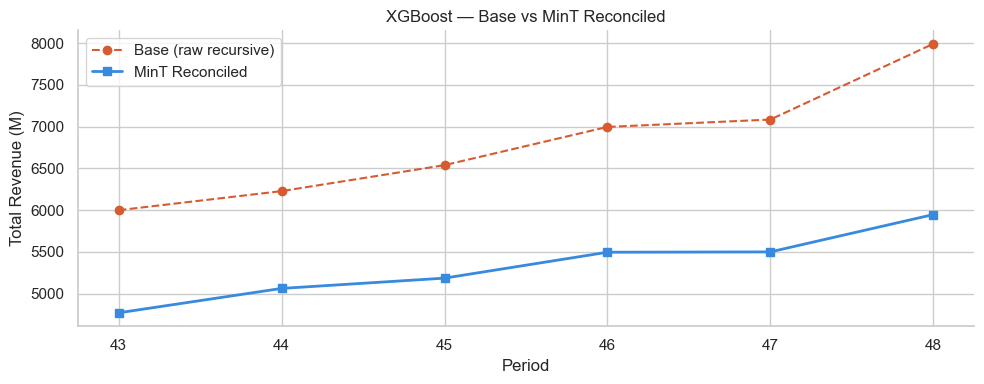

In [21]:
# ═══════════════════════════════════════════════════════════════
# 7.8c  Compare base vs reconciled forecasts
# ═══════════════════════════════════════════════════════════════
# NOTE: Run this cell AFTER Cell 36 (Final Predictions with MinT).
#       It uses recon_sub, recon_total, and base_preds_flat from Cell 36.

# Sum base subsegment forecasts per period (raw recursive, no MinT)
base_per_period = (
    submission_base
    .groupby(PERIOD_COL)['Revenue_Base']
    .sum()
    .values
)

recon_per_period = (
    submission
    .groupby(PERIOD_COL)['Revenue_Predicted']
    .sum()
    .values
)

periods = sorted(submission[PERIOD_COL].unique())

comparison = pd.DataFrame({
    'Period': periods,
    'Base_Total': base_per_period,
    'Reconciled_Total': recon_per_period,
    'Difference': recon_per_period - base_per_period,
    'Pct_Change': (recon_per_period - base_per_period) / (np.abs(base_per_period) + 1e-8) * 100
})

print(f'=== {BEST_MODEL}: Base vs MinT Reconciled (Total Revenue) ===\n')
for _, row in comparison.iterrows():
    print(f"  Period {int(row['Period']):>2d}:  "
          f"Base {row['Base_Total']:>14,.0f}  →  "
          f"MinT {row['Reconciled_Total']:>14,.0f}  "
          f"({row['Pct_Change']:>+.1f}%)")

total_base  = comparison['Base_Total'].sum()
total_recon = comparison['Reconciled_Total'].sum()
total_pct   = (total_recon - total_base) / (abs(total_base) + 1e-8) * 100
print(f"\n  {'TOTAL':>10}:  Base {total_base:>14,.0f}  →  MinT {total_recon:>14,.0f}  ({total_pct:>+.1f}%)")

# Quick visual
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(periods, base_per_period / 1e6, 'o--', label='Base (raw recursive)', color='#D85A30')
ax.plot(periods, recon_per_period / 1e6, 's-', label='MinT Reconciled', color='#378ADD', linewidth=2)
ax.set_xlabel('Period')
ax.set_ylabel('Total Revenue (M)')
ax.set_title(f'{BEST_MODEL} — Base vs MinT Reconciled')
ax.legend()
sns.despine()
plt.tight_layout()
plt.show()


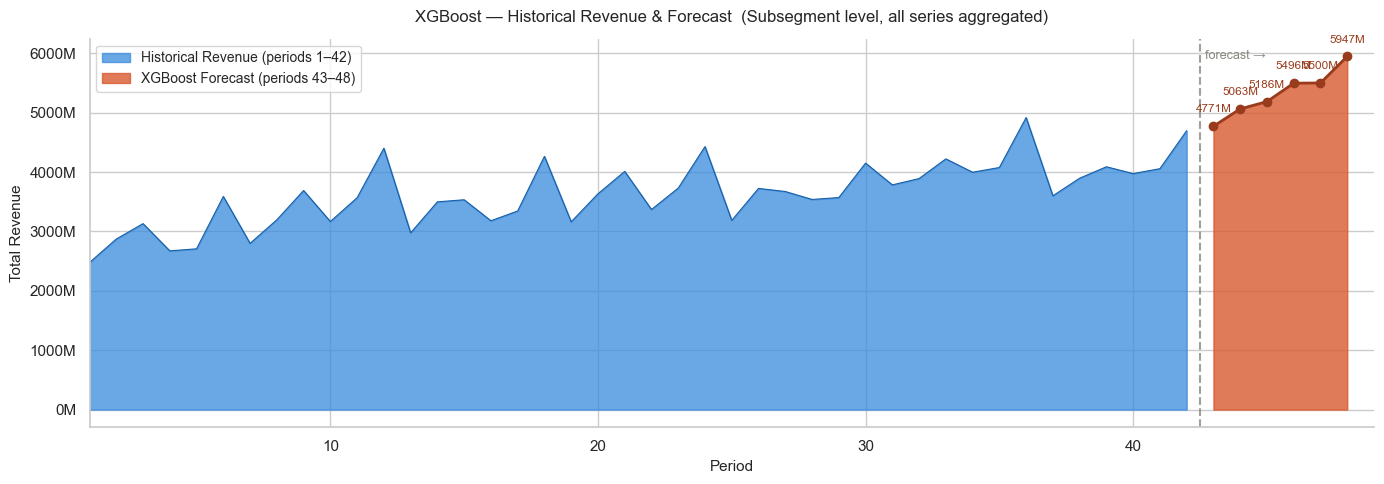

WindowsPath('../data/results/forecast_plot_xgboost.png')

In [22]:
fm.plot_forecast_comparison(
    train_df=train_full,
    submission_df=submission,
    period_col=PERIOD_COL,
    target_col=TARGET,
    best_model_name=BEST_MODEL,
    output_dir=output_dir
)

In [23]:
# Subsegments no treino vs no test
train_subs = set(zip(train_full[BU_COL], train_full[SEG_COL], train_full[SUBSEG_COL]))
test_subs  = set(zip(test_df[BU_COL],   test_df[SEG_COL],   test_df[SUBSEG_COL]))

print(f'Unique series in train : {len(train_subs)}')
print(f'Unique series in test  : {len(test_subs)}')
print(f'In test but NOT train  : {len(test_subs - train_subs)}')
print(f'In train but NOT test  : {len(train_subs - test_subs)}')
phantom = test_subs - train_subs
for s in phantom:
    print(f'  BU={s[0]}  Seg={s[1]}  Subseg={s[2]}')

Unique series in train : 134
Unique series in test  : 123
In test but NOT train  : 0
In train but NOT test  : 11


---
## Summary

| Aspect | Notebook 6 | This notebook |
|--------|-----------|---------------|
| Splits | 1 (fixed) | 6 (walk-forward) |
| Horizon | 6 periods (recursive) | 1 period (direct) |
| Lag features | Recomputed recursively | Pre-computed (valid for h=1) |
| Use case | Final model selection | Stability & calibration check |